## Polytech Paris Saclay | 3ème année


## TP4 Algo Num 1: Equation de la chaleur

Rappel du cours
===============

Modélisation du problème
------------------------

On souhaite modéliser la distribution spatiale de la température $u(x)$
dans une barre de longueur 1 mètre qui est un contact avec une source de
chaleur dont la température a une distribution spatiale non homogène. La
température aux deux extrémités de la barre est fixée à une valeur
finie, qu’on appelle 0 (mais qui n’est pas le zéro absolu de la
température). La température $u(x)$ vérife l’équation **(1)** suivante :
$$\frac{d^2u}{dx^2}(x)=f(x), \qquad x\in ]0,1[ $$ avec **(2)** : $$u(0)=u(1)=0.$$
Le terme $f(x)$ décrit la source de chaleur.

Discrétisation du problème
--------------------------

On discrétise $x$ en $N$ segments élémentaires de même longueur avec un
pas $h$ constant, on a **(3)**: $$h= \frac{1}{N}$$ et **(4)**$$x_k= kh$$


1.  On approxime $u(x_{k})$ par $v_k$ dans un schéma aux différences finies. L'équation **(1)** se traduit numériquement par **(5)**: $$\frac{v_{k-1} - 2 v_k + v_{k+1}}{h^2}= f(x_k)$$
avec **(6)** $$v_0=v_N=0$$

2.  Montrer que l’équation **(5)** peut se ré-écrire sous la forme
    matricielle **(7)** suivante où $f_k=f(x_k)$: $$\frac{1}{h^2}
       \left (
       \begin{array}{ccccc}
       -2 & 1 & \dots  & 0 & 0 \\
         1 & -2 &  1 & \ddots & \vdots \\
         0 &  \ddots&  \ddots  & \ddots &  0 \\
         \vdots &  \ddots&  1  & -2 &  1 \\
          0  &  \dots &  0   & 1 &  -2 \\
       \end{array}
       \right )
        \left (
       \begin{array}{c}
       v_1 \\
         v_2  \\
          \vdots \\
            \vdots \\
         v_{N-2}  \\
         v_{N-1} \\
       \end{array}
       \right )
        =
        \left (
       \begin{array}{c}
       f_1 \\
         f_2  \\
          \vdots \\
            \vdots \\
         f_{N-2}  \\
         f_{N-1} \\
       \end{array}
       \right )$$ Dans la suite, on appellera $A$ la matrice utilisée
    pour la définition du problème.

Construction d'un problème dont on pourra établir la solution exacte.
----------------------------

On souhaite mesurer à la fin du TP l’erreur d’approximation $erreur\_approx$ de la
résolution de la chaleur définie ainsi **(8)** :

$erreur \_approx = \max_i |  v_i - u(x_i) |$

où $u(i)$ est la solution
exacte de l’équation **(1)**.\
Nous devons donc choisir une fonction $f(x)$ pour laquelle nous pouvons
établir une solution analytique de l’équation **(1)**. 
- Déterminer théoriquement la solution exacte $u$ de l’équation **(1)** pour la fonction $f$ suivante:
$$f(x) = 4 \pi ^2 \sin ( 2 \pi x).$$

$u''(x) = 4 \pi^2 sin(\pi x)$

$u'(x) = 4 \pi^2 \frac{1}{2 \pi} cos(2 \pi x) + c_0$

$u(x) = -sin(2 \pi x)$

Expérimentations sous Python
============================


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as sla

Production de la matrice $A$
-------------

Écrire la fonction **calcul\_A()** qui détermine $A$ en fonction de
$N$. La matrice $A$ pourra être construite comme la somme de trois diagonales.

In [2]:
def calcul_A(N):
    h = 1/N
    prefix = 1/h**2

    A = prefix * ((np.eye(N-1) * -2) + (np.eye(N-1, k=1)) + (np.eye(N-1, k=-1)))

    return A

Donner la matrice $A$ pour $N = 20$:

In [119]:
N = 20

A = calcul_A(N)

print(A)

[[-800.  400.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.]
 [ 400. -800.  400.    0.    0.    0.    0.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.]
 [   0.  400. -800.  400.    0.    0.    0.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.  400. -800.  400.    0.    0.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.  400. -800.  400.    0.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0.  400. -800.  400.    0.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0.    0.  400. -800.  400.    0.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0.    0.    0.  400. -800.  400.    0.    0.    0.
     0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0.    0.    0.    0.  400

Production du vecteur $f$
-----------

Écrire la fonction **calcul\_f()** qui détermine le vecteur $f$ en
fonction de $N$. On rappelle que $\pi$ se calcule avec np.pi en python.

In [109]:
def calcul_f(N):
    h = 1/N
    x = lambda k: k * h
    F = np.zeros(shape=(N-1))
    for i in range(1, N-1):
        F[i - 1] = (4 * (np.pi ** 2) * np.sin(2 * np.pi * x(i)))
    return F

F = calcul_f(N)

Donner $f$ pour $N=20$ et afficher le graphe de $f$

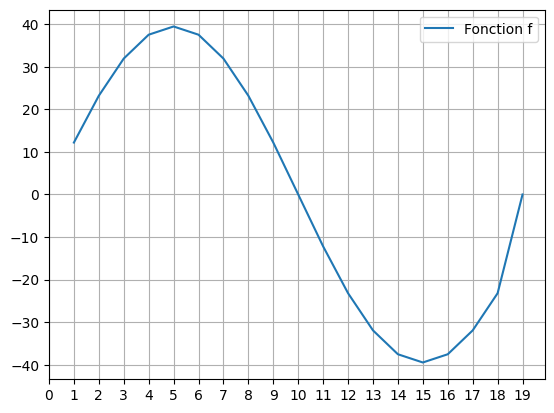

In [ ]:
N = 20  

plt.plot(
    range(1, N),
    calcul_f(N),
    label="Fonction f"
)

plt.xticks(range(0, N))

plt.grid()
plt.legend()

plt.show()

Calcul de la solution approchée $v$ qui résoud l'équation $Av=f$
-----------------------------------

Écrire la fonction **calcul\_v()** qui détermine le vecteur $v$ en
fonction de $N$.
- On pourra utiliser les fonctions Descente, Montee, MonLUInPlace et SolveLU du TP2.


In [104]:
# FONCTION IMPORTEES DU TP2 JORDAN LAVENANT

def Montee(U, b):
    for i in range(np.shape(U)[0]):
        if U[i][i] == 0:
            raise ValueError("La matrice U n'est pas inversible")

    n = len(b)
    x = np.zeros(n)

    for i in range(n - 1, -1, -1):
        somme = 0
        for j in range(i + 1, n):
            somme += U[i][j] * x[j]

        x[i] = (b[i] - somme) / U[i][i]
    
    return x

def Descente(L, b):
    for i in range(np.shape(L)[0]):
        if L[i][i] == 0:
            raise ValueError("La matrice L n'est pas inversible")

    n = len(b)
    x = np.zeros(n)

    for i in range(n):
        somme = 0
        for j in range(i):
            somme += L[i][j] * x[j]

        x[i] = (b[i] - somme) / L[i][i]
    
    return x

def MonLUInPlace(A):
    n = A.shape[0]
    N = A.copy().astype(float)
    
    for i in range(n):
        # Calcul de U (ligne i)
        for j in range(i, n):
            somme = 0
            for k in range(i):
                somme += N[i][k] * N[k][j]
            N[i][j] = N[i][j] - somme
        
        # Vérification pivot
        if N[i][i] == 0:
            raise ValueError("Pivot nul, échec de LU sans pivot")
        
        # Calcul de L (colonne i)
        for j in range(i + 1, n):
            somme = 0
            for k in range(i):
                somme += N[j][k] * N[k][i]
            
            N[j][i] = (N[j][i] - somme) / N[i][i]
    
    return N

def ExtractLU(N):
    n = N.shape[0]
    L = np.eye(n) + np.tril(N, k=-1) # Diagonale = 1
    U = np.triu(N)
    return L, U

def SolveLU(A, b):
    N = MonLUInPlace(A)
    L, U = ExtractLU(N)
    y = Descente(L, b)
    x = Montee(U, y)
    return x

In [ ]:
def calcul_v(N):
    return SolveLU(A, calcul_f(N))

- Donner $v$ pour $N=20$:

In [106]:
N = 20

v = calcul_v(N)

print(v)

[-0.31309609 -0.59569342 -0.82027867 -0.96501715 -1.01589011 -0.96806702
 -0.82637842 -0.60484304 -0.32529559 -0.01524938  0.29479683  0.57434429
  0.79587967  0.93756827  0.98539135  0.93451839  0.78977992  0.56519466
  0.28259733]


- vérifier que $v$ résoud bien l'équation:

In [112]:
np.allclose(A @ v, F)

True

- utiliser sla.solve(A,f) pour déterminer $v$ et valider une fois de plus votre vecteur $v$ calculé ci-dessus.

In [114]:
resultat = sla.solve(A, F)

print(resultat)

np.allclose(v, sla.solve(A, F))

[-0.31309609 -0.59569342 -0.82027867 -0.96501715 -1.01589011 -0.96806702
 -0.82637842 -0.60484304 -0.32529559 -0.01524938  0.29479683  0.57434429
  0.79587967  0.93756827  0.98539135  0.93451839  0.78977992  0.56519466
  0.28259733]


True

Comparaison de la solution exacte $u(x)$ et de la solution approchée $v$
------------------------------------------------------------------------




### Production de la solution exacte $u(x$)


En utilisant l'expression mathématique de la solution exacte trouvée en introduction, écrire la fonction **calcul\_sol\_exact()** prenant en entrée le
nombre de segments élémentaires $N$. Cette fonction retourne le vecteur
$x$ de taille $N+1$ ainsi que le vecteur sol\_exact contenant la
solution $u(x_i)$, déterminée ci-dessus, sur chaque point
$x_i$.

In [ ]:
def calcul_sol_exact(N):
    x = np.linspace(0, 1, N+1)
    sol_exact = -np.sin(2 * np.pi * x)

    return x, sol_exact

Donner le vecteur $u_{ex}$ pour $N = 20$:

In [176]:
x, sol_exact = calcul_sol_exact(N)

Calculer l'erreur d'approximation pour $N=20$: $$erreur\_approx = \max_i |  v_i - u_{ex}(x_i) |$$

In [ ]:
# erreur_aprox = max()

Calculer l'erreur d'approximation pour $N=10$. Interpréter le résultat.

Tracer sur un même graphique les valeurs pontuelles de la solution
exacte $u(x)$, de la solution approchée $v$ et de l’erreur
d’approximation $erreur\_approx$ et ce pour différentes valeurs de $N$.
Interpréter les résultats.